In [1]:
from qiskit_nature.second_q.hamiltonians import HeisenbergModel
from qiskit_nature.second_q.hamiltonians.lattices import line_lattice
from qiskit_nature.second_q.mappers import LogarithmicMapper
from qiskit import QuantumCircuit
nqb = 5
line = line_lattice.LineLattice(nqb)
H = LogarithmicMapper().map(HeisenbergModel(line, (1,1,1)).second_q_op())
Hmat = H.to_matrix()

In [2]:
import numpy as np 
e,v = np.linalg.eigh(Hmat)
gs_id = np.argsort(e)[:2]
gs_1 = v[:, gs_id[0]]
gs_2 = v[:, gs_id[1]]

In [8]:
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator

def sample_haar_su2():
    alpha = np.random.uniform(0, 2 * np.pi)
    u     = np.random.uniform(0, 1)
    beta  = 2 * np.arccos(np.sqrt(u))   # absorbs sin(β) Jacobian
    gamma = np.random.uniform(0, 2 * np.pi)
    return alpha, beta, gamma

gs_1_sv = Statevector(gs_1)
gs_2_sv = Statevector(gs_2)

mixed_state = 0.5 * np.outer(gs_1, gs_1.conj()) + 0.5 * np.outer(gs_2, gs_2.conj())
mixed_distance = []
mixed_unnorm = np.zeros([2**nqb, 2**nqb], dtype = complex)
energies = []
for t in range(1001):
    random_su2 = QuantumCircuit(nqb)
    alpha, beta, gamma = sample_haar_su2()
    for i in range(nqb):
        random_su2.rz(gamma, i)
        random_su2.ry(beta, i)
        random_su2.rz(alpha, i)
    test_mat = Operator(random_su2).data
    assert(np.allclose(test_mat @ Hmat - Hmat @ test_mat, np.zeros([2**nqb, 2**nqb])))
    gs_t = gs_1_sv.evolve(random_su2).data
    mixed_unnorm += np.outer(gs_t, gs_t.conj())
    energies.append(np.trace(Hmat @ np.outer(gs_t, gs_t.conj())))
    mixed_distance.append(np.linalg.norm(mixed_state - mixed_unnorm/np.complex128(t+1)))

Text(0.5, 0, 'samples')

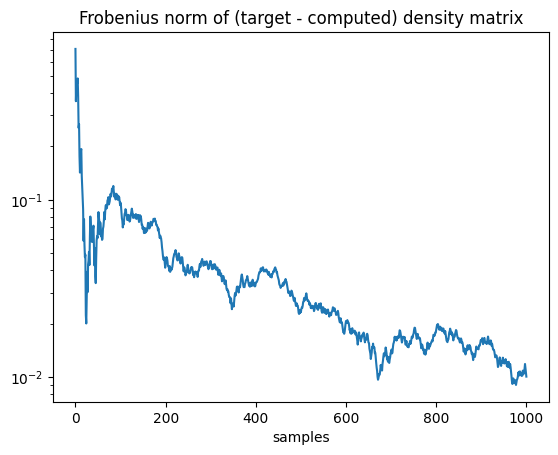

In [9]:
import matplotlib.pyplot as plt
plt.semilogy(mixed_distance)
plt.title('Frobenius norm of (target - computed) density matrix')
plt.xlabel('samples')